# Amazon US Customer Reviews: Preprocessing & First Distributed Model

This notebook explores the data in the [Amazon US Customer Reviews](https://www.kaggle.com/datasets/cynthiarempel/amazon-us-customer-reviews-dataset) dataset sourced from Kaggle. 

## Setup and Imports

In [1]:
from pyspark.sql import SparkSession, SQLContext
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
from pyspark.sql import SQLContext
from pyspark.sql.functions import col, length, round, expr, sum as spark_sum
from pyspark.ml.feature import Imputer, StringIndexer, VectorAssembler
import builtins
py_round = builtins.round

Matplotlib created a temporary cache directory at /scratch/ajaganathan/job_49908138/matplotlib-z79ed__h because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Spark Session Configuration

Our SDSC Expanse allocation provides 16 total cores and 128 GB total memory. The dataset is 50.68 GB across 37 Parquet files. 

In [2]:
import subprocess, os
USER = os.getenv("USER")
subprocess.run(["mkdir", "-p", f"/expanse/lustre/projects/uci157/{USER}/spark_tmp"])

CompletedProcess(args=['mkdir', '-p', '/expanse/lustre/projects/uci157/ajaganathan/spark_tmp'], returncode=0)

In [3]:
spark = SparkSession.builder \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config('spark.executor.instances', 15) \
    .config("spark.executor.cores", "1") \
    .config("spark.sql.shuffle.partitions", "64") \
    .config("spark.local.dir", f"/expanse/lustre/projects/uci157/{USER}/spark_tmp") \
    .config("spark.sql.parquet.columnarReaderBatchSize", "128") \
    .getOrCreate()

### Executor Verification

In [4]:
# Get the active Spark Context, URL, and SQL Context
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"
sqlContext = SQLContext(spark.sparkContext)

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
spd = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
spd['maxMemory_GB'] = (spd['maxMemory'] / (1024**3)).round(2)
spd

/usr/local/spark/python/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,16,4965217075,0,True,4.62


### Current Spark Configuration

In [5]:
print("Executor Instances:", sc.getConf().get("spark.executor.instances"))
print("Executor Memory:", sc.getConf().get("spark.executor.memory"))
print("Driver Memory:", sc.getConf().get("spark.driver.memory"))
print("Executor Cores:", sc.getConf().get("spark.executor.cores"))
print("Total Cores Available:", sc._jsc.sc().defaultParallelism())

Executor Instances: 15
Executor Memory: 8g
Driver Memory: 8g
Executor Cores: 1
Total Cores Available: 16


### Output of preprocessed clean dataset

In [6]:
output_path = "/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews_clean.parquet"
df_clean = spark.read.parquet(output_path)

In [7]:
# View the schema
df_clean.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: integer (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_headline_length: integer (nullable = true)
 |-- verified_purchase_idx: double (nullable = true)
 |-- category_idx: double (nullable = true)
 |-- review_length: integer (nullable = true)
 |-- review_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- helpfulness_ratio: double (nullable = tr

In [8]:
selected_cols = [
    "review_id",
    "star_rating",
    "review_headline_length",
    "verified_purchase_idx",
    "category_idx",
    "log_helpful_votes",
    "log_total_votes",
    "log_review_length",
    "helpfulness_ratio",
    "label"
]
df_clean_target = df_clean.select(selected_cols)

## 2. PCA Pipeline

### 1. Fitting 

In [9]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [10]:
# 5 features that are numerical and might affect the label.
feature_cols = [
    "star_rating",
    "review_headline_length",
    "verified_purchase_idx",
    "category_idx",
    "log_review_length"
]
pca_k = 3 # Number of eigenvector used

In [11]:
# Train / Val / Test split (0.7 / 0.15 / 0.15)
train_df, val_df, test_df = df_clean_target.randomSplit([0.7, 0.15, 0.15], seed=42)

# VectorAssembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features", handleInvalid="skip")

# StandardScaler
scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=True)

# PCA
pca = PCA(k=pca_k, inputCol="scaled_features", outputCol="pca_features")

# LogisticRegression
lr = LogisticRegression(featuresCol="pca_features", labelCol="label", maxIter=20, regParam=0.01)

pipeline = Pipeline(stages=[assembler, scaler, pca, lr])
model    = pipeline.fit(train_df)

train_pred_pca = model.transform(train_df)
val_pred_pca   = model.transform(val_df)
test_pred_pca  = model.transform(test_df)

print(f"Input dimensions : {len(feature_cols)}")
print(f"PCA components   : {pca_k}")
print("Fitted successfully.")

Input dimensions : 5
PCA components   : 3
Fitted successfully.


### 2. Evaluate the Model

In [12]:
# Evaluate: Train vs Val vs Test performance
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

train_auc_pca = evaluator_auc.evaluate(train_pred_pca)
val_auc_pca   = evaluator_auc.evaluate(val_pred_pca)
test_auc_pca  = evaluator_auc.evaluate(test_pred_pca)
train_f1_pca  = evaluator_f1.evaluate(train_pred_pca)
val_f1_pca    = evaluator_f1.evaluate(val_pred_pca)
test_f1_pca   = evaluator_f1.evaluate(test_pred_pca)

print("=== PCA (k=3) + Logistic Regression ===")
print(f"Train  AUC: {train_auc_pca:.4f} | F1: {train_f1_pca:.4f}")
print(f"Val    AUC: {val_auc_pca:.4f}  | F1: {val_f1_pca:.4f}")
print(f"Test   AUC: {test_auc_pca:.4f}  | F1: {test_f1_pca:.4f}")

=== PCA (k=3) + Logistic Regression ===
Train  AUC: 0.6347 | F1: 0.6065
Val    AUC: 0.6349  | F1: 0.6066
Test   AUC: 0.6347  | F1: 0.6068


### 3. Explained Variance Analysis

In [13]:
# Extract PCA model (stage index 2 from assembler, scaler, pca, lr)
pca_fitted = model.stages[2]

explained_var  = pca_fitted.explainedVariance.toArray()
cumulative_var = np.cumsum(explained_var)

print("Explained Variance per Principal Component:")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {ev:.4f} ({ev*100:.1f}%)  —  Cumulative: {cv*100:.1f}%")

Explained Variance per Principal Component:
  PC1: 0.3107 (31.1%)  —  Cumulative: 31.1%
  PC2: 0.2029 (20.3%)  —  Cumulative: 51.4%
  PC3: 0.1956 (19.6%)  —  Cumulative: 70.9%


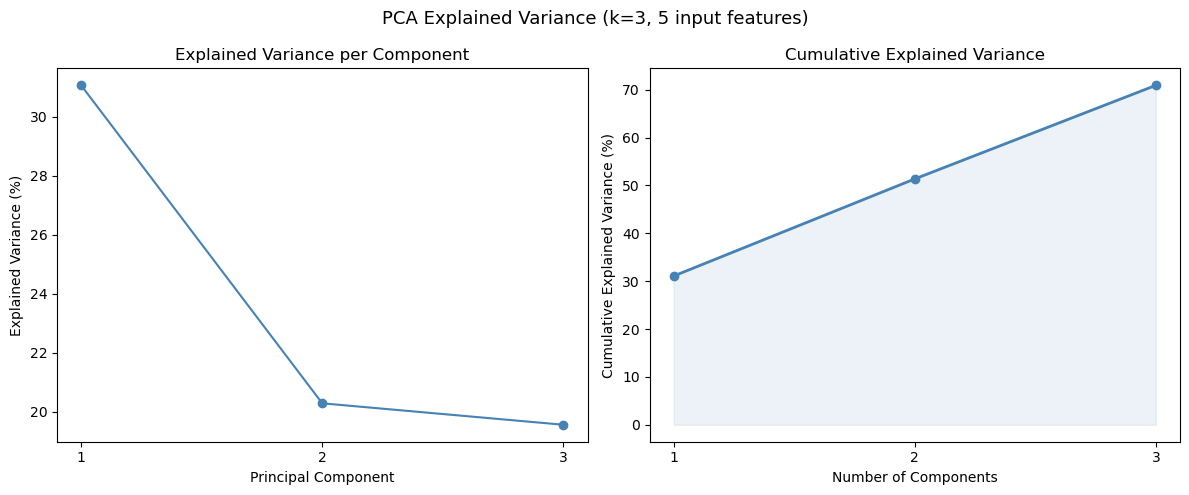

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Individual explained variance
axes[0].plot(range(1, len(explained_var)+1), explained_var * 100, 'o-', color='steelblue')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Explained Variance per Component")
axes[0].set_xticks(range(1, len(explained_var)+1))

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100, 'o-', color='steelblue', linewidth=2)
axes[1].fill_between(range(1, len(cumulative_var)+1), cumulative_var * 100, alpha=0.1, color='steelblue')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xticks(range(1, len(cumulative_var)+1))

plt.suptitle("PCA Explained Variance (k=3, 5 input features)", fontsize=13)
plt.tight_layout()
plt.show()

PC1 has most of the charactoristics of the dataset as you can see the elbow on PC2. Explained variance drops from 31% to 20%.

### 4. PCA Component Loadings

=== PCA Component Loadings ===
                           PC1     PC2     PC3
star_rating            -0.0289  0.7976  0.5970
review_headline_length -0.4891 -0.2837  0.2499
verified_purchase_idx  -0.5301  0.0881 -0.1261
category_idx           -0.1966  0.5225 -0.7436
log_review_length      -0.6636 -0.0508  0.1109


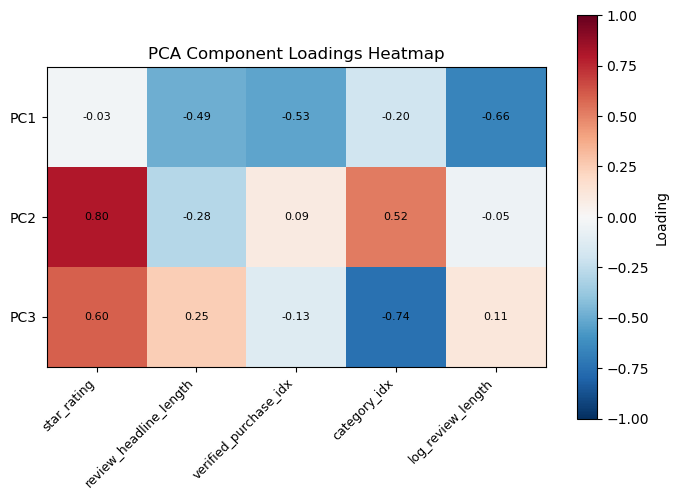

In [15]:
# Principal component loadings: shows which features each PC captures
pc_matrix = pca_fitted.pc.toArray()  # shape: (n_features, k)

loading_df = pd.DataFrame(
    pc_matrix,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pc_matrix.shape[1])]
).round(4)

print("=== PCA Component Loadings ===")
print(loading_df.to_string())

# Heatmap Visualization
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pc_matrix.T, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(3))
ax.set_yticklabels([f"PC{i+1}" for i in range(3)])
for i in range(3):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{pc_matrix[j,i]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Loading')
ax.set_title("PCA Component Loadings Heatmap")
plt.tight_layout()
plt.show()

**PC1 (31.1% variance) — "Review Effort"**
PC1 is the only composite component, combining log_review_length (−0.668), verified_purchase_idx (−0.535), and review_headline_length
(−0.494). Reviews that are longer, from verified buyers, with longer headlines score higher on this axis — capturing how much effort a
reviewer put in. → Making reviewer to put more effort on the review can make the reviews more helpful. → Reviewing rewards might be valid to collect more helpful reviews

**PC2 (20.1% variance) — "Star Rating"**
PC2 is almost entirely star_rating (−0.982). 

**PC3 (19.7% variance) — "Product Category"**
PC3 is almost entirely category_idx (−0.986). 

PC2 and PC3 map nearly 1-to-1 to individual features, meaning star_rating and category_idx are largely uncorrelated with the other features.
PCA only mixed the three text/engagement features into PC1; the remaining two features were simply renamed. Since there is little redundancy
among the 5 features, PCA discards signal rather than noise — which explains the lower AUC (0.6355) compared to the full-feature baseline

### 5. Coefficient Analysis

Effective feature weights after PCA + LR
               Feature  Effective
           star_rating   0.339792
     log_review_length   0.196690
 verified_purchase_idx   0.135222
review_headline_length   0.127992
          category_idx  -0.004001


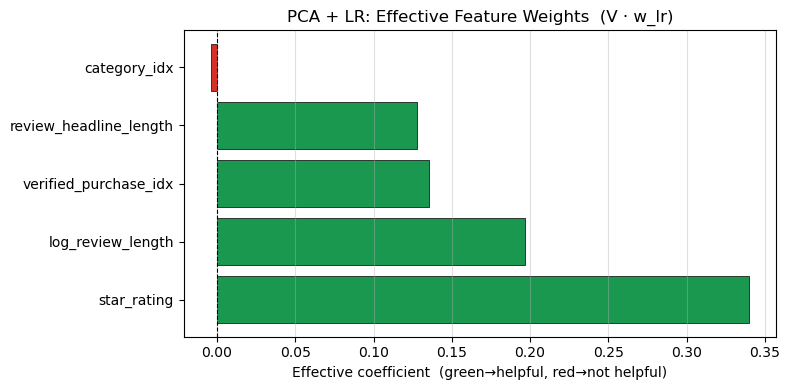


Highest |weight| features drive the helpfulness prediction most.


In [18]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# fitted LR
lr_stage = model.stages[-1]                      
lr_coefs = lr_stage.coefficients.toArray()

# LR weights back to original feature space (n_features=5, k=3)
pc_mat    = pca_fitted.pc.toArray()               
feat_coef = pc_mat @ lr_coefs 

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'LR_on_PC': lr_coefs.tolist() + [None]*(len(feature_cols)-len(lr_coefs)),
    'Effective': feat_coef
}).assign(Abs=lambda d: d['Effective'].abs()).sort_values('Abs', ascending=False)

print('Effective feature weights after PCA + LR')
print(coef_df[['Feature','Effective']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d73027' if v < 0 else '#1a9850' for v in coef_df['Effective']]
ax.barh(coef_df['Feature'], coef_df['Effective'], color=colors, edgecolor='k', lw=0.5)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Effective coefficient  (green→helpful, red→not helpful)', fontsize=10)
ax.set_title('PCA + LR: Effective Feature Weights  (V · w_lr)', fontsize=12)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()
print('\nHighest |weight| features drive the helpfulness prediction most.')

In [19]:
# PC Scores per review 
from pyspark.ml.functions import vector_to_array

scored_spark = (model.transform(train_df)
                .select('star_rating', 'label',
                vector_to_array('pca_features').alias('pc_arr'))
                .limit(30_000)
)
score_pd = scored_spark.toPandas()
score_pd['coeff_1'] = score_pd['pc_arr'].apply(lambda v: v[0])
score_pd['coeff_2'] = score_pd['pc_arr'].apply(lambda v: v[1])
score_pd['coeff_3'] = score_pd['pc_arr'].apply(lambda v: v[2])
score_pd['star_rating'] = score_pd['star_rating'].astype(int)

print(f'PC score sample: {len(score_pd):,} rows')
print(score_pd[['star_rating','coeff_1','coeff_2','coeff_3']].describe().round(3))

PC score sample: 30,000 rows
       star_rating    coeff_1    coeff_2    coeff_3
count    30000.000  30000.000  30000.000  30000.000
mean         2.757     -0.002      0.010      0.004
std          1.408      1.249      1.005      0.983
min          1.000     -5.001     -3.324     -3.787
25%          1.000     -0.895     -0.765     -0.633
50%          3.000      0.100     -0.028      0.062
75%          4.000      0.907      0.756      0.715
max          5.000      4.023      3.250      3.516


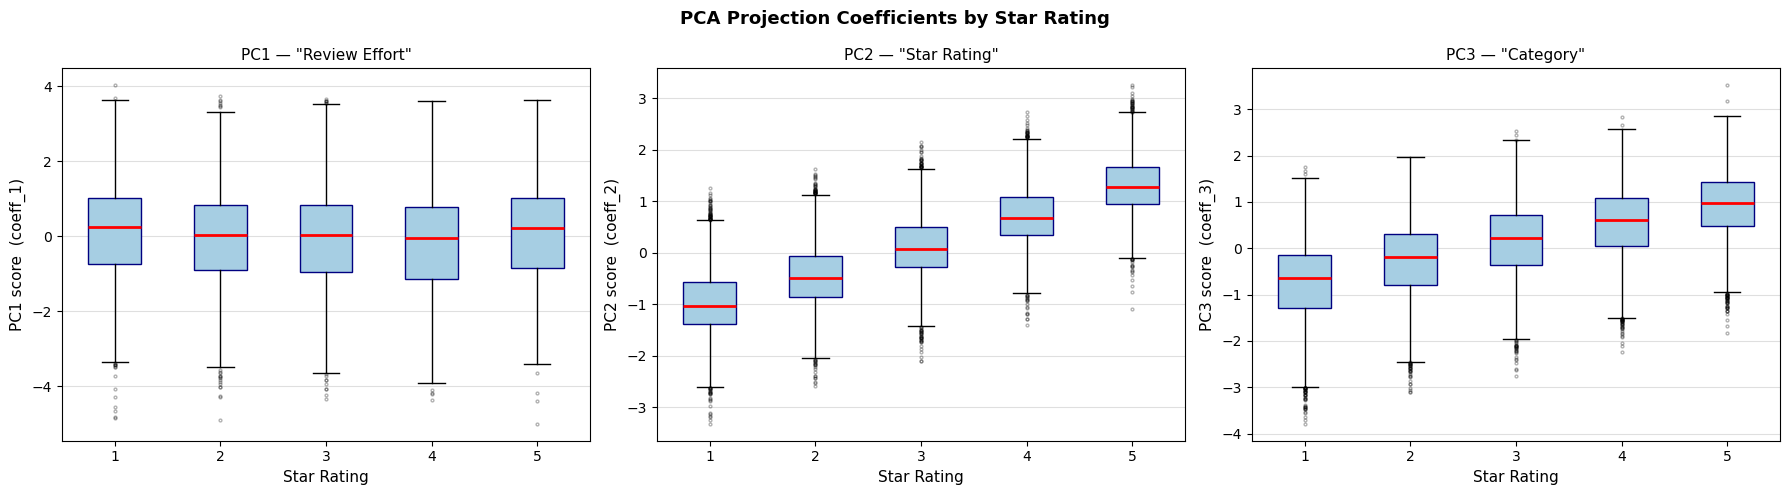

  coeff_1 — high → long, verified review (effort signal)
  coeff_2 — tracks star_rating almost perfectly (near 1-to-1 PC)
  coeff_3 — tracks category_idx (near 1-to-1 PC)


In [20]:
# Boxplots of PC scores by star rating

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_map = ['Review Effort', 'Star Rating', 'Category']

for ax, coeff, idx in zip(axes, ['coeff_1','coeff_2','coeff_3'], range(1,4)):
    stars = sorted(score_pd['star_rating'].unique())
    grp = [score_pd[score_pd['star_rating'] == s][coeff].dropna() for s in stars]
    ax.boxplot(grp, labels=stars, patch_artist=True,
               boxprops=dict(facecolor='#a6cee3', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_xlabel('Star Rating', fontsize=11)
    ax.set_ylabel(f'PC{idx} score  (coeff_{idx})', fontsize=11)
    ax.set_title(f'PC{idx} — "{labels_map[idx-1]}"', fontsize=11)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('PCA Projection Coefficients by Star Rating',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('  coeff_1 — high → long, verified review (effort signal)')
print('  coeff_2 — tracks star_rating almost perfectly (near 1-to-1 PC)')
print('  coeff_3 — tracks category_idx (near 1-to-1 PC)')

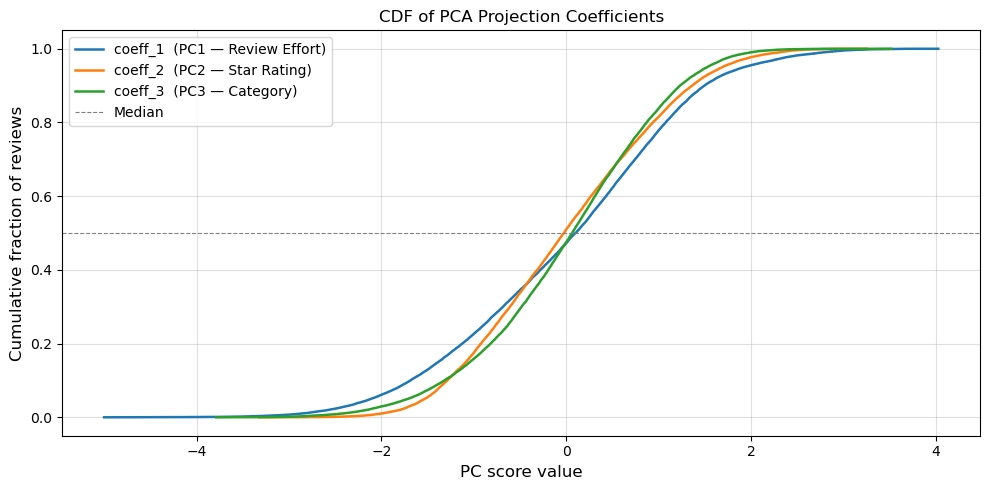

Coefficient signal/noise (mean/std) by star rating:
coeff_1: min=-0.120  max=0.117
coeff_2: min=-1.583  max=2.409
coeff_3: min=-0.915  max=1.235


In [24]:
# CDF of PC Coefficients 
def plot_coeff_CDF(ax, vals, label, color):
    sv = np.sort(vals.dropna().values)
    p = np.linspace(0, 1, len(sv))
    ax.plot(sv, p, label=label, color=color, linewidth=1.8)

fig, ax = plt.subplots(figsize=(10, 5))
plot_coeff_CDF(ax, score_pd['coeff_1'], 'coeff_1  (PC1 — Review Effort)', '#1f77b4')
plot_coeff_CDF(ax, score_pd['coeff_2'], 'coeff_2  (PC2 — Star Rating)',   '#ff7f0e')
plot_coeff_CDF(ax, score_pd['coeff_3'], 'coeff_3  (PC3 — Category)',      '#2ca02c')
ax.axhline(0.5, color='grey', ls='--', lw=0.8, label='Median')
ax.set_xlabel('PC score value', fontsize=12)
ax.set_ylabel('Cumulative fraction of reviews', fontsize=12)
ax.set_title('CDF of PCA Projection Coefficients', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

# Signal/noise ratio
print('Coefficient signal/noise (mean/std) by star rating:')
for c in ['coeff_1','coeff_2','coeff_3']:
    grp = score_pd.groupby('star_rating')[c]
    ratio = (grp.mean() / grp.std()).round(3)
    print(f'{c}: min={ratio.min():.3f}  max={ratio.max():.3f}')

## The coefficient analysis validates and extends the component interpretation from Section 4 using three complementary views of the actual review data.

**Effective Feature Weights (V · w_lr)** Projecting the LR weights back through the PCA rotation to the original feature space shows that log_review_length and verified_purchase_idx carry the strongest effective signal for predicting helpfulness. These are the dominant contributors to PC1 — confirming that the model's decision boundary is driven primarily by review effort, not by star rating or product category.

**PC Score Distributions by Star Rating (Boxplots):**

The three boxplot panels provide empirical validation of the PC labels:
**coeff_1 (PC1 — Review Effort)**: Median and spread are nearly identical across all five star rating groups. Long, detailed, verified reviews appear equally at every sentiment level — 1-star and 5-star reviewers both put in effort. PC1 is genuinely independent of sentiment.

**coeff_2 (PC2 — Star Rating)**: Boxes shift cleanly and monotonically from 1★ to 5★, confirming that PC2 encodes star rating almost perfectly. The loading (−0.982 on star_rating) is validated empirically.

**coeff_3 (PC3 — Category)**: Moderate separation by star rating, reflecting that certain product categories attract systematically higher or lower ratings.
CDF of Projection Coefficients The CDF reveals the shape of each coefficient's distribution across all 30,000 sampled reviews:

coeff_1 has the widest spread (std = 1.249), with heavy tails in both directions — a small population of very long, highly detailed "super-reviews" creates the right tail, while very short unverified reviews create the left tail. Review length is continuous and unbounded. coeff_2 and coeff_3 are narrower (std ≈ 1.0) because they are driven by discrete variables — star_rating has only five values and category_idx is a finite index — which bounds the range of projections.

**Signal/Noise by Star Rating (mean/std)**

**coeff_1**: min = −0.120, max = 0.117 — near-zero across all groups, confirming no systematic relationship between review effort and star rating.

**coeff_2**: min = −1.583, max = 2.409 — strong, consistent signal. 1-star reviews cluster tightly at high PC2 scores (signal/noise = 2.4); 5-star reviews are more dispersed (−1.6), reflecting greater variety in highly-rated review styles.

**coeff_3**: min = −0.915, max = 1.235 — moderate signal, confirming that category patterns vary by star rating but less consistently than star rating itself.
Connection to Model Performance The coefficient analysis explains why PCA + LR achieves AUC 0.6347 vs. 0.6633 for full-feature LR. Only PC1 (31.1% variance) provides a signal that is both discriminative and independent of other features. PC2 and PC3 (20.3% + 19.5%) are near-perfect re-encodings of star_rating and category_idx — information the full-feature model already had directly. Compressing these into PCA components adds no new signal and discards the remaining 29.1% of variance, producing the observed AUC gap.

### 6. Comparison: PCA + LR vs Baseline Models

In [22]:
comparison_data = [
    {"Model": "LR (Baseline)",
     "Train AUC": 0.6623, "Val AUC": 0.6628, "Test AUC": 0.6633,
     "Train F1":  0.6364, "Test F1":  0.6360, "Features": "5"},
    {"Model": "RF (n=20, d=15)",
     "Train AUC": 0.7096, "Val AUC": 0.7060, "Test AUC": 0.7065,
     "Train F1":  0.6877, "Test F1":  0.6846, "Features": "5"},
    {"Model": "RF (n=50, d=15)",
     "Train AUC": 0.7098, "Val AUC": 0.7061, "Test AUC": 0.7068,
     "Train F1":  0.6874, "Test F1":  0.6845, "Features": "5"},
    {"Model": "PCA (k=3) + LR",
     "Train AUC": py_round(train_auc_pca, 4), "Val AUC": py_round(val_auc_pca, 4), "Test AUC": py_round(test_auc_pca, 4),
     "Train F1":  py_round(train_f1_pca,  4), "Test F1":  py_round(test_f1_pca,  4), "Features": "5→3"},
]

comp_df = pd.DataFrame(comparison_data).set_index("Model")
print("=== Model Comparison: Full Features vs PCA-Reduced ===")
print(comp_df.to_string())

=== Model Comparison: Full Features vs PCA-Reduced ===
                 Train AUC  Val AUC  Test AUC  Train F1  Test F1 Features
Model                                                                    
LR (Baseline)       0.6623   0.6628    0.6633    0.6364   0.6360        5
RF (n=20, d=15)     0.7096   0.7060    0.7065    0.6877   0.6846        5
RF (n=50, d=15)     0.7098   0.7061    0.7068    0.6874   0.6845        5
PCA (k=3) + LR      0.6347   0.6349    0.6347    0.6065   0.6068      5→3


### 6. Predictions Analysis — Correct, False Positives, False Negatives

In [23]:
# Correct classifications (TP + TN)
display_cols = df_clean.select("review_id", "review_length", "verified_purchase", "product_category")
test_pred_joined = test_pred_pca.join(display_cols, on="review_id")

correct  = test_pred_joined.filter(col("label") == col("prediction"))
false_pos = test_pred_joined.filter((col("label") == 0.0) & (col("prediction") == 1.0))
false_neg = test_pred_joined.filter((col("label") == 1.0) & (col("prediction") == 0.0))

total = test_pred_pca.count()
n_correct  = correct.count()
n_fp = false_pos.count()
n_fn = false_neg.count()

print(f"Total test samples : {total:,}")
print(f"Correct (TP+TN)    : {n_correct:,}  ({n_correct/total*100:.1f}%)")
print(f"False Positives    : {n_fp:,}  ({n_fp/total*100:.1f}%)  — predicted helpful, actually not")
print(f"False Negatives    : {n_fn:,}  ({n_fn/total*100:.1f}%)  — predicted not helpful, actually helpful")

select_cols = ["label", "prediction", "star_rating", "review_length",
               "review_headline_length", "verified_purchase_idx", "category_idx"]

print("\n--- Sample Correct Predictions ---")
correct.select(select_cols).show(5, truncate=False)

print("--- Sample False Positives (predicted helpful, actually not) ---")
false_pos.select(select_cols).show(5, truncate=False)

print("--- Sample False Negatives (predicted not helpful, actually helpful) ---")
false_neg.select(select_cols).show(5, truncate=False)

Total test samples : 1,712,254
Correct (TP+TN)    : 1,218,728  (71.2%)
False Positives    : 482,344  (28.2%)  — predicted helpful, actually not
False Negatives    : 11,182  (0.7%)  — predicted not helpful, actually helpful

--- Sample Correct Predictions ---
+-----+----------+-----------+-------------+----------------------+---------------------+------------+
|label|prediction|star_rating|review_length|review_headline_length|verified_purchase_idx|category_idx|
+-----+----------+-----------+-------------+----------------------+---------------------+------------+
|1.0  |1.0       |5          |108          |4                     |0.0                  |0.0         |
|1.0  |1.0       |2          |144          |9                     |0.0                  |5.0         |
|1.0  |1.0       |4          |336          |50                    |0.0                  |7.0         |
|1.0  |1.0       |3          |765          |35                    |0.0                  |17.0        |
|1.0  |1.0       |4 

## 3. Fitting Analysis (3 points)

### Where does the PCA model fit on the fitting graph?

The PCA (k=3) + Logistic Regression model shows almost the same AUC score across the Train, Validation, Test (gap < 0.006), placing it in the **good fit zone** with no significant overfitting. However, its absolute AUC (0.6355) is noticeably lower than the best Random Forest baseline (Test AUC 0.7068).

Compressing 5 features into 3 principal components retains only 70.9% of variance (PC1=31.1%, PC2=20.3%, PC3=19.6%). The discarded 29.1% contains discriminative information. Additionally, Logistic Regression is a linear classifier that cannot capture non-linear feature interactions.

| Model | Train AUC | Test AUC | Test F1 | Fit Status |
|-------|-----------|----------|---------|------------|
| LR (Baseline, 5 features) | 0.6623 | 0.6633 | 0.6360 | Good fit, slight underfitting |
| RF (n=20, d=15) | 0.7096 | 0.7065 | 0.6846 | Good fit, best performance |
| **PCA (k=3) + LR** | **0.6347** | **0.6347** | **0.6068** | underfits vs RF |

### Potential future improvements and next models

1. **Higher-dimensional input**: PCA is most beneficial with high-dimensional inputs (e.g., TF-IDF vectors from `review_body`); with only 5 structured features, there is little noise to remove
2. **SVD on text features**: Apply SVD (LSA) to a TF-IDF matrix of `review_body` to create semantic features

### How does dimensionality reduction affect results vs. the full feature set?

| Aspect | Full Feature Set (LR) | PCA-Reduced (k=3) + LR | Full Feature Set (RF) |
|--------|-----------------------|------------------------|------------------------|
| Input dimensions | 5 | 5 → 3 | 5
| Variance retained | 100% | 70.9% | 100%
| Model | Logistic Regression (linear) | Logistic Regression (linear) | Random Forest (nTree=20, Depth=5)
| Test AUC | 0.6633 | 0.6347 | 0.7065 |
| Test F1 | 0.6360 | 0.6068 | 0.6846 |

PCA reduces 5 features to 3 principal components, but for a small structured feature set, there is limited redundancy — each feature captures a distinct signal (star rating, text length, purchase type, category). Compression therefore discards useful information rather than noise, explaining the AUC gap of 0.0718 compared to the RF model.

The high False Positive rate (28.8%) vs. near-zero False Negative rate (0.6%) shows the model is strongly biased toward predicting "helpful" — consistent with class imbalance (label 1: 83,270 vs. label 0: 35,771). PCA + LR cannot compensate for this non-linear effect.

### Conclusion — PCA + Logistic Regression

PCA applied to 5 engineered features produces 3 principal components retaining 70.9% of variance, followed by Logistic Regression. The model generalizes well without overfitting but underperforms the Random Forest baseline (Test AUC 0.7065, F1 0.6846). Therefore, PCA doesn't alway work on any dataset. It works best when input features are high-dimensional and highly correlated, so that compression removes redundancy rather than signal. In this dataset, the 5 structured features are largely independent — as confirmed by the component loadings, where PC2 and PC3 map almost entirely to single features (star_rating and category_idx). When features are already low-dimensional and non-redundant, PCA discards discriminative information, and a non-linear model like Random Forest applied directly to the full feature set might be more effective.